In [1]:
import os, pandas as pd, matplotlib.pyplot as plt
os.chdir(os.path.expanduser("~/growth-marketing-analytics"))
ga = pd.read_parquet("data/processed/ga_sessions.parquet")
ga["new_visitor"] = ga.visit_number == 1
OUT = "module_2_google_analytics/outputs/"
print(ga.shape)

TypeError: data type 'dbdate' not understood

In [2]:
import os, pandas as pd, matplotlib.pyplot as plt
import db_dtypes
os.chdir(os.path.expanduser("~/growth-marketing-analytics"))
ga = pd.read_parquet("data/processed/ga_sessions.parquet")

ga["date"] = pd.to_datetime(ga["date"].astype(str))
ga.to_parquet("data/processed/ga_sessions.parquet", index=False)

ga["new_visitor"] = ga.visit_number == 1
OUT = "module_2_google_analytics/outputs/"
print(ga.shape, ga.date.dtype)

(903653, 19) datetime64[us]


In [3]:
buy = ga.transactions > 0
kpi = pd.Series({
    "Sessions": len(ga),
    "Users": ga.visitor_id.nunique(),
    "Bounce rate %": ga.bounce.mean()*100,
    "Pages per session": ga.pageviews.mean(),
    "Conversion rate %": buy.mean()*100,
    "Orders": ga.transactions.sum(),
    "Revenue $": ga.revenue.sum(),
    "AOV $": ga.revenue.sum()/ga.transactions.sum(),
    "Revenue per session $": ga.revenue.sum()/len(ga),
}).round(2)
kpi.to_csv(OUT + "overall_kpis.csv")
kpi

Sessions                  903653.00
Users                     714167.00
Bounce rate %                 49.87
Pages per session              3.85
Conversion rate %              1.28
Orders                     12115.00
Revenue $                1540071.24
AOV $                        127.12
Revenue per session $          1.70
dtype: float64

In [4]:
ch = ga.groupby("channel").agg(
    sessions=("session_id","count"),
    users=("visitor_id","nunique"),
    bounce_rate=("bounce","mean"),
    pages_per_session=("pageviews","mean"),
    buying_sessions=("transactions", lambda x: (x>0).sum()),
    orders=("transactions","sum"),
    revenue=("revenue","sum"),
    new_visitor_share=("new_visitor","mean"),
)
ch["session_share_%"] = ch.sessions / ch.sessions.sum() * 100
ch["revenue_share_%"] = ch.revenue / ch.revenue.sum() * 100
ch["conversion_rate_%"] = ch.buying_sessions / ch.sessions * 100
ch["aov"] = ch.revenue / ch.orders
ch["revenue_per_session"] = ch.revenue / ch.sessions
ch["bounce_rate"] *= 100
ch["new_visitor_share"] *= 100
ch = ch.sort_values("revenue", ascending=False).round(2)
ch.to_csv(OUT + "channel_scorecard.csv")
ch[["sessions","session_share_%","revenue","revenue_share_%","conversion_rate_%","aov","revenue_per_session","bounce_rate"]]

KeyError: "Label(s) ['session_id'] do not exist"

In [5]:
import os, pandas as pd, matplotlib.pyplot as plt
os.chdir(os.path.expanduser("~/growth-marketing-analytics"))
ga = pd.read_parquet("data/processed/ga_sessions.parquet")

ga["session_id"] = ga.visitor_id + "_" + ga.visit_id.astype(str)
ga.to_parquet("data/processed/ga_sessions.parquet", index=False)

ga["new_visitor"] = ga.visit_number == 1
OUT = "module_2_google_analytics/outputs/"
print(ga.shape, ga.date.dtype)


(903653, 20) datetime64[us]


In [6]:
buy = ga.transactions > 0
kpi = pd.Series({
    "Sessions": len(ga),
    "Users": ga.visitor_id.nunique(),
    "Bounce rate %": ga.bounce.mean()*100,
    "Pages per session": ga.pageviews.mean(),
    "Conversion rate %": buy.mean()*100,
    "Orders": ga.transactions.sum(),
    "Revenue $": ga.revenue.sum(),
    "AOV $": ga.revenue.sum()/ga.transactions.sum(),
    "Revenue per session $": ga.revenue.sum()/len(ga),
}).round(2)
kpi.to_csv(OUT + "overall_kpis.csv")
kpi

Sessions                  903653.00
Users                     714167.00
Bounce rate %                 49.87
Pages per session              3.85
Conversion rate %              1.28
Orders                     12115.00
Revenue $                1540071.24
AOV $                        127.12
Revenue per session $          1.70
dtype: float64

In [7]:
ch = ga.groupby("channel").agg(
    sessions=("session_id","count"),
    users=("visitor_id","nunique"),
    bounce_rate=("bounce","mean"),
    pages_per_session=("pageviews","mean"),
    buying_sessions=("transactions", lambda x: (x>0).sum()),
    orders=("transactions","sum"),
    revenue=("revenue","sum"),
    new_visitor_share=("new_visitor","mean"),
)
ch["session_share_%"] = ch.sessions / ch.sessions.sum() * 100
ch["revenue_share_%"] = ch.revenue / ch.revenue.sum() * 100
ch["conversion_rate_%"] = ch.buying_sessions / ch.sessions * 100
ch["aov"] = ch.revenue / ch.orders
ch["revenue_per_session"] = ch.revenue / ch.sessions
ch["bounce_rate"] *= 100
ch["new_visitor_share"] *= 100
ch = ch.sort_values("revenue", ascending=False).round(2)
ch.to_csv(OUT + "channel_scorecard.csv")
ch[["sessions","session_share_%","revenue","revenue_share_%","conversion_rate_%","aov","revenue_per_session","bounce_rate"]]

,sessions,session_share_%,revenue,revenue_share_%,conversion_rate_%,aov,revenue_per_session,bounce_rate
channel,,,,,,,,
Referral,104838,11.60,651429.91,42.30,5.08,117.52,6.21,25.98
Direct,143026,15.83,434840.55,28.24,1.44,195.96,3.04,49.56
Organic Search,381561,42.22,326380.51,21.19,0.9,91.14,0.86,48.32
Display,6262,0.69,78337.46,5.09,2.28,515.38,12.51,35.87
Paid Search,25326,2.80,43558.90,2.83,1.85,90.94,1.72,38.01
Social,226117,25.02,4916.54,0.32,0.05,37.53,0.02,65.24
Affiliates,16403,1.82,597.38,0.04,0.05,66.38,0.04,53.05
(Other),120,0.01,9.99,0.00,0.83,9.99,0.08,46.67


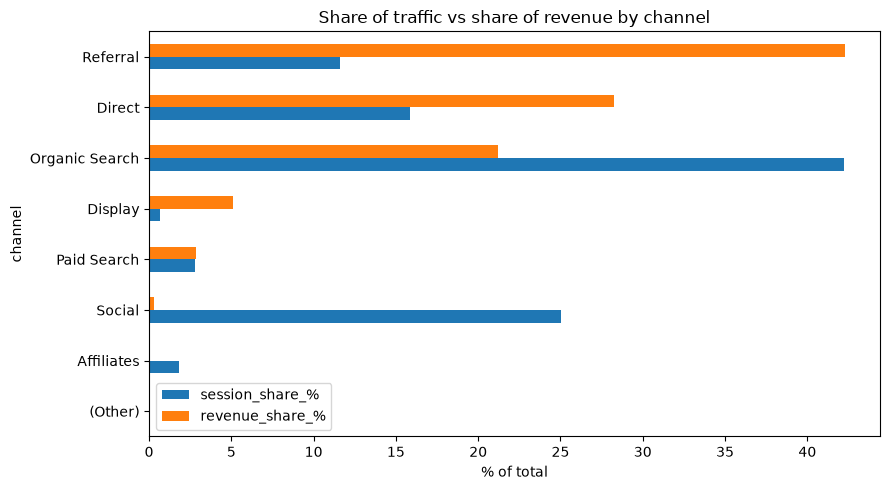

In [8]:
plot = ch[["session_share_%","revenue_share_%"]].sort_values("revenue_share_%")
ax = plot.plot.barh(figsize=(9,5))
ax.set_xlabel("% of total")
ax.set_title("Share of traffic vs share of revenue by channel")
plt.tight_layout(); plt.savefig(OUT + "traffic_vs_revenue_share.png", dpi=150); plt.show()

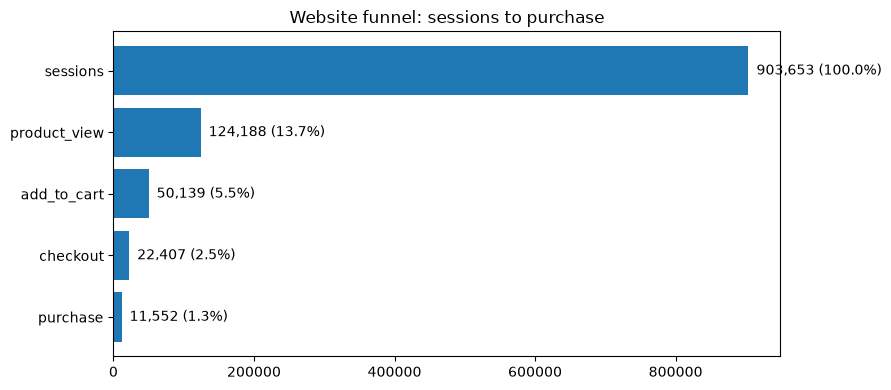

,count,% of sessions,% from previous step,drop-off %
sessions,903653,100.00,NaN,NaN
product_view,124188,13.74,13.74,86.26
add_to_cart,50139,5.55,40.37,59.63
checkout,22407,2.48,44.69,55.31
purchase,11552,1.28,51.56,48.44


In [9]:
stages = ["product_view","add_to_cart","checkout","purchase"]
f = pd.Series({"sessions": len(ga), **{s: ga[s].sum() for s in stages}})
funnel = pd.DataFrame({"count": f})
funnel["% of sessions"] = funnel["count"] / len(ga) * 100
funnel["% from previous step"] = funnel["count"] / funnel["count"].shift(1) * 100
funnel["drop-off %"] = 100 - funnel["% from previous step"]
funnel = funnel.round(2)
funnel.to_csv(OUT + "funnel_overall.csv")

fig, ax = plt.subplots(figsize=(9,4))
ax.barh(funnel.index[::-1], funnel["count"][::-1])
for i, (c, p) in enumerate(zip(funnel["count"][::-1], funnel["% of sessions"][::-1])):
    ax.text(c, i, f"  {c:,.0f} ({p:.1f}%)", va="center")
ax.set_title("Website funnel: sessions to purchase")
plt.tight_layout(); plt.savefig(OUT + "funnel_overall.png", dpi=150); plt.show()
funnel

In [10]:
fc = ga.groupby("channel")[stages].sum()
fc.insert(0, "sessions", ga.groupby("channel").size())
fc["view_rate_%"]     = fc.product_view / fc.sessions * 100
fc["cart_rate_%"]     = fc.add_to_cart / fc.product_view * 100
fc["checkout_rate_%"] = fc.checkout / fc.add_to_cart * 100
fc["purchase_rate_%"] = fc.purchase / fc.checkout * 100
fc["overall_cvr_%"]   = fc.purchase / fc.sessions * 100
fc = fc.round(2).sort_values("overall_cvr_%", ascending=False)
fc.to_csv(OUT + "funnel_by_channel.csv")
fc[["sessions","view_rate_%","cart_rate_%","checkout_rate_%","purchase_rate_%","overall_cvr_%"]]

,sessions,view_rate_%,cart_rate_%,checkout_rate_%,purchase_rate_%,overall_cvr_%
channel,,,,,,
Referral,104838,25.94,49.71,61.54,63.98,5.08
Display,6262,23.33,37.03,42.7,61.9,2.28
Paid Search,25326,20.03,37.49,40.54,60.83,1.85
Direct,143026,14.76,43.76,46.98,47.49,1.44
Organic Search,381561,16.42,35.71,36.64,42.0,0.9
(Other),120,15.0,22.22,75.0,33.33,0.83
Affiliates,16403,11.35,42.75,17.34,6.52,0.05
Social,226117,2.13,36.71,23.09,25.49,0.05


In [11]:
dv = ga.groupby("device").agg(sessions=("session_id","count"),
        buying=("transactions", lambda x: (x>0).sum()),
        revenue=("revenue","sum"), bounce=("bounce","mean"))
dv["session_share_%"] = dv.sessions/dv.sessions.sum()*100
dv["conversion_rate_%"] = dv.buying/dv.sessions*100
dv["revenue_per_session"] = dv.revenue/dv.sessions
dv["bounce_rate_%"] = dv.bounce*100
dv = dv.drop(columns="bounce").round(2)
dv.to_csv(OUT + "device_performance.csv")
dv

,sessions,buying,revenue,session_share_%,conversion_rate_%,revenue_per_session,bounce_rate_%
device,,,,,,,
desktop,664479,10528,1480864.09,73.53,1.58,2.23,49.22
mobile,208725,856,49785.81,23.10,0.41,0.24,51.96
tablet,30449,168,9421.34,3.37,0.55,0.31,49.62


In [12]:
nr = ga.groupby("new_visitor").agg(sessions=("session_id","count"),
        buying=("transactions", lambda x: (x>0).sum()), revenue=("revenue","sum"))
nr.index = nr.index.map({True:"New", False:"Returning"})
nr["conversion_rate_%"] = nr.buying/nr.sessions*100
nr["revenue_share_%"] = nr.revenue/nr.revenue.sum()*100
nr["revenue_per_session"] = nr.revenue/nr.sessions
nr = nr.round(2)
nr.to_csv(OUT + "new_vs_returning.csv")
nr

,sessions,buying,revenue,conversion_rate_%,revenue_share_%,revenue_per_session
new_visitor,,,,,,
Returning,200593,7077,1157745.28,3.53,75.17,5.77
New,703060,4475,382325.96,0.64,24.83,0.54


In [13]:
co = ga.groupby("country").agg(sessions=("session_id","count"), revenue=("revenue","sum"))
co["revenue_share_%"] = co.revenue/co.revenue.sum()*100
co["revenue_per_session"] = co.revenue/co.sessions
co = co.sort_values("revenue", ascending=False).head(10).round(2)
co.to_csv(OUT + "top_countries.csv")
co

,sessions,revenue,revenue_share_%,revenue_per_session
country,,,,
United States,364744,1452440.65,94.31,3.98
Canada,25869,32824.54,2.13,1.27
Venezuela,2132,13374.90,0.87,6.27
Japan,19731,6728.99,0.44,0.34
Kenya,771,5268.70,0.34,6.83
Nigeria,1446,3302.40,0.21,2.28
Taiwan,12996,1920.89,0.12,0.15
Indonesia,9273,1840.38,0.12,0.20
Australia,12698,1745.26,0.11,0.14


In [14]:
biggest_leak = funnel["drop-off %"].iloc[1:].idxmax()
print(f"""
Top revenue channel: {ch.index[0]} ({ch['revenue_share_%'].iloc[0]:.1f}% of revenue from {ch['session_share_%'].iloc[0]:.1f}% of traffic)
Highest conversion channel: {fc.index[0]} ({fc['overall_cvr_%'].iloc[0]:.2f}%)
Lowest conversion channel: {fc.index[-1]} ({fc['overall_cvr_%'].iloc[-1]:.2f}%)
Biggest funnel leak: into '{biggest_leak}' ({funnel.loc[biggest_leak,'drop-off %']:.1f}% drop-off)
Returning visitors convert {nr.loc['Returning','conversion_rate_%']/nr.loc['New','conversion_rate_%']:.1f}x better than new visitors
Desktop CVR: {dv.loc['desktop','conversion_rate_%']:.2f}% | Mobile CVR: {dv.loc['mobile','conversion_rate_%']:.2f}%
""")


Top revenue channel: Referral (42.3% of revenue from 11.6% of traffic)
Highest conversion channel: Referral (5.08%)
Lowest conversion channel: Social (0.05%)
Biggest funnel leak: into 'product_view' (86.3% drop-off)
Returning visitors convert 5.5x better than new visitors
Desktop CVR: 1.58% | Mobile CVR: 0.41%



In [15]:
ref = ga[ga.channel == "Referral"].groupby("source").agg(
    sessions=("session_id","count"), revenue=("revenue","sum"),
    buying=("transactions", lambda x: (x>0).sum()))
ref["revenue_share_%"] = ref.revenue / ref.revenue.sum() * 100
ref["cvr_%"] = ref.buying / ref.sessions * 100
ref.sort_values("revenue", ascending=False).head(10).round(2)

,sessions,revenue,buying,revenue_share_%,cvr_%
source,,,,,
(direct),68933,615391.69,5136,94.47,7.45
mail.google.com,1457,23327.91,62,3.58,4.26
dealspotr.com,528,5690.64,40,0.87,7.58
sites.google.com,2983,4390.78,42,0.67,1.41
connect.googleforwork.com,97,404.81,3,0.06,3.09
mg.mail.yahoo.com,34,377.31,4,0.06,11.76
siliconvalley.about.com,2097,377.22,6,0.06,0.29
google.com,4669,347.24,5,0.05,0.11
phandroid.com,222,271.74,6,0.04,2.7


In [16]:
soc = ga[ga.channel == "Social"].groupby("source").agg(
    sessions=("session_id","count"), revenue=("revenue","sum"),
    bounce=("bounce","mean"))
soc["session_share_%"] = soc.sessions / soc.sessions.sum() * 100
soc.sort_values("sessions", ascending=False).head(10).round(3)

,sessions,revenue,bounce,session_share_%
source,,,,
youtube.com,212602,314.07,0.66,94.023
m.facebook.com,3365,186.80,0.61,1.488
facebook.com,2296,1137.67,0.521,1.015
reddit.com,2022,7.97,0.41,0.894
quora.com,1546,25.98,0.431,0.684
t.co,1529,267.68,0.704,0.676
groups.google.com,1025,1631.26,0.42,0.453
l.facebook.com,795,1043.72,0.631,0.352
plus.google.com,524,205.43,0.49,0.232


In [17]:
d = ga[(ga.channel == "Display") & (ga.transactions > 0)]
print("Display buying sessions:", len(d))
print("Median order value:", round((d.revenue / d.transactions).median(), 2))
print("Mean order value:  ", round((d.revenue / d.transactions).mean(), 2))
print("Top 5 orders share of Display revenue: {:.1%}".format(
    d.revenue.nlargest(5).sum() / d.revenue.sum()))

Display buying sessions: 143
Median order value: 73.74
Mean order value:   439.48
Top 5 orders share of Display revenue: 61.2%
